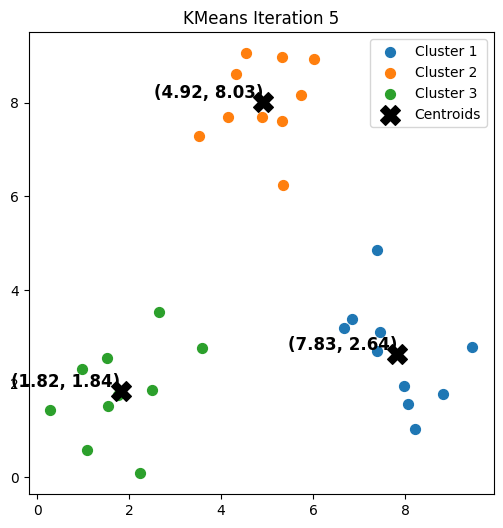

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
# 1️⃣ Create a synthetic dataset
np.random.seed(42)
points_cluster1 = np.random.randn(10, 2) + np.array([2, 2])
points_cluster2 = np.random.randn(10, 2) + np.array([8, 3])
points_cluster3 = np.random.randn(10, 2) + np.array([5, 8])
X = np.vstack((points_cluster1, points_cluster2, points_cluster3))
# Number of clusters
k = 3
# 2️⃣ Initialize centroids randomly
random_idx = np.random.choice(len(X), k, replace=False)
centroids = X[random_idx]
# Store steps for animation
steps = [(X.copy(), centroids.copy(), np.zeros(len(X)))]
# 3️⃣ Implement KMeans
for _ in range(5):  # Run for 5 iterations for visualization
   # Step 1: Assign points to nearest centroid
   distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
   labels = np.argmin(distances, axis=1)
   # Step 2: Update centroids
   new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
   steps.append((X.copy(), new_centroids.copy(), labels.copy()))
   # Step 3: Check for convergence
   if np.all(centroids == new_centroids):
       break
   centroids = new_centroids
# 4️⃣ Create GIF animation
fig, ax = plt.subplots(figsize=(6, 6))
def update(frame):
   ax.clear()
   X_step, centroids_step, labels_step = steps[frame]
   for i in range(k):
       cluster_points = X_step[labels_step == i]
       ax.scatter(cluster_points[:, 0], cluster_points[:, 1], s=50, label=f'Cluster {i+1}')
   ax.scatter(centroids_step[:, 0], centroids_step[:, 1], c='black', marker='X', s=200, label='Centroids')
   for i, (cx, cy) in enumerate(centroids_step):
       ax.text(cx, cy, f'({cx:.2f}, {cy:.2f})', fontsize=12, color='black', ha='right', va='bottom', fontweight='bold')
   ax.set_title(f'KMeans Iteration {frame}')
   ax.legend()
ani = FuncAnimation(fig, update, frames=len(steps), repeat=False)
ani.save('kmeans_animation.gif', writer=PillowWriter(fps=1))
plt.show()